In [ ]:
# Дослідження ринку праці в AI 2025-2026: Криза досвіду та роль Remote.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
try:
    df = pd.read_csv('ai_job_dataset.csv')
    print("✅ Файл успішно завантажено!")
except FileNotFoundError:
    print("❌ Помилка: Файл 'ai_job_dataset.csv' не знайдено в цій папці.")

✅ Файл успішно завантажено!


In [30]:
# Data Cleaning
rows_before = len(df)
df = df.drop_duplicates()
print(f"✅ Видалено дублікатів: {rows_before - len(df)}")

Q1 = df['salary_usd'].quantile(0.25)
Q3 = df['salary_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['salary_usd'] >= lower_bound) & (df['salary_usd'] <= upper_bound)].copy()
print(f"✅ Очищено від аномалій. Залишилося рядків: {len(df_clean)} (було {len(df)})")

missing_salaries = df_clean['salary_usd'].isnull().sum()
if missing_salaries > 0:
    df_clean = df_clean.dropna(subset=['salary_usd'])
    print(f"✅ Видалено {missing_salaries} рядків без вказаної зарплати.")
else:
    print("✅ Пропусків у зарплатах не виявлено.")
df = df_clean


✅ Видалено дублікатів: 0
✅ Очищено від аномалій. Залишилося рядків: 14517 (було 15000)
✅ Пропусків у зарплатах не виявлено.


In [31]:
display(df.head())

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,...,posting_date,application_deadline,job_description_length,benefits_score,company_name,Market_Type,Market_Strategy,Strategy_Group,Category,Location_Display
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,...,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,Other,Other (Small Markets),Other,3. Emerging Markets,China
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,...,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,Remote Layer (Global),4. Remote Layer (Global),4. Remote Layer (Global),4. Remote Layer (Global),Global Remote Talent
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,...,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,Other,Other (Small Markets),1. High-paying Markets,1. High-paying Markets,Switzerland
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,...,2024-12-23,2025-02-24,1345,8.6,Future Systems,Other,Other (Small Markets),3. Emerging Markets,3. Emerging Markets,India
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,...,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics,Remote Layer (Global),4. Remote Layer (Global),4. Remote Layer (Global),4. Remote Layer (Global),Global Remote Talent


In [32]:
print(df.columns.tolist())

['job_id', 'job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name', 'Market_Type', 'Market_Strategy', 'Strategy_Group', 'Category', 'Location_Display']


In [33]:
experience_salaries = df.groupby('experience_level')['salary_usd'].median().sort_values()

print("--- МЕДІАННА ЗАРПЛАТА ПО РІВНЯХ ($) ---")
print(experience_salaries)

--- МЕДІАННА ЗАРПЛАТА ПО РІВНЯХ ($) ---
experience_level
EN     60373.5
MI     84641.0
SE    116907.0
EX    167899.0
Name: salary_usd, dtype: float64


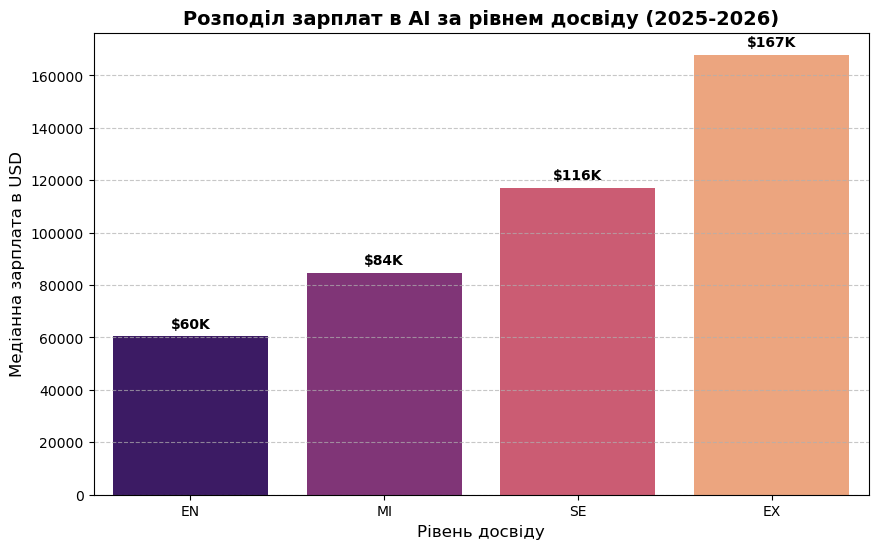

In [34]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(x=experience_salaries.index, 
                 y=experience_salaries.values, 
                 hue=experience_salaries.index, 
                 palette='magma', 
                 legend=False)

plt.title('Розподіл зарплат в AI за рівнем досвіду (2025-2026)', fontsize=14, fontweight='bold')
plt.ylabel('Медіанна зарплата в USD', fontsize=12)
plt.xlabel('Рівень досвіду', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'${int(p.get_height()/1000)}K', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.show()

ratio = senior_sal / junior_sal

print("="*70)


================================================================================
📊 АНАЛІТИЧНИЙ ЗВІТ: ТРАНСФОРМАЦІЯ РИНКУ ПРАЦІ В AI (2025-2026)
================================================================================

Дане дослідження базується на очищеному датасеті (видалено аномалії методом IQR). 
Отримані результати демонструють зміну структури компенсацій під впливом автоматизації:

1️⃣ СТАТИСТИЧНЕ ПІДТВЕРДЖЕННЯ "СТИCНЕННЯ" РИНКУ:
Зафіксований коефіцієнт розриву між рівнями EN (Junior) та SE (Senior) становить 1.94. 
Це значно нижче історичного ринкового стандарту (2.5–3.0). Статистика вказує на 
корекцію вартості технічних навичок через зростання продуктивності Junior-спеціалістів, 
що використовують LLM-інструменти.

2️⃣ НОРМАЛІЗАЦІЯ "ФІНАНСОВОЇ ПІДЛОГИ":
Медіанна зарплата початкового рівня (EN) зафіксована на позначці $60k. 
Високий рівень входу корелює зі зміною очікувань до технічного стеку: 
базове написання коду перейшло з категорії 'експертизи' до категорії 'базової навички'.

3️⃣ ПРЕМІЯ ЗА СТРАТЕГІЧНИЙ РІВЕНЬ (EXECUTIVE):
Найбільший приріст у доходах спостерігається при переході від Senior до Executive 
управління (+43.6%). Це свідчить про те, що капіталізація фахівця зміщується 
від виконання технічних завдань до прийняття стратегічних рішень та управління ризиками.

💡 ВИСНОВОК: 
Дані підтверджують гіпотезу про зміну конкурентного ландшафту. Основна додана вартість 
фахівця з даних у 2026 році зміщується від операційного аналізу («Як порахувати?») 
до стратегічного консалтингу («Яку бізнес-проблему ми вирішуємо?»).

================================================================================

In [21]:

market_groups = {
    'United States': '1. High-paying Markets',
    'Switzerland': '1. High-paying Markets',
    'Germany': '2. Balanced Markets',
    'United Kingdom': '2. Balanced Markets',
    'India': '3. Emerging Markets',
    'Brazil': '3. Emerging Markets',
    'China': '3. Emerging Markets'
}

def get_final_structure(row):
    if row['remote_ratio'] == 100:
        return ('4. Remote Layer (Global)', 'Global Remote Talent')
    cat = market_groups.get(row['company_location'], 'Other')
    return (cat, row['company_location'])

df[['Category', 'Location_Display']] = df.apply(
    lambda x: pd.Series(get_final_structure(x)), axis=1
)

final_detailed_report = df[df['Category'] != 'Other'].pivot_table(
    index=['Category', 'Location_Display'], 
    columns='experience_level', 
    values='salary_usd', 
    aggfunc='median'
)

final_cols = [c for c in ['EN', 'MI', 'SE', 'EX'] if c in final_detailed_report.columns]
final_detailed_report = final_detailed_report[final_cols].dropna(subset=['EN', 'SE'])
final_detailed_report['Exp_Premium_%'] = ((final_detailed_report['SE'] / final_detailed_report['EN']) - 1) * 100

display(final_detailed_report.style.format({
    'EN': format_with_k, 'MI': format_with_k, 
    'SE': format_with_k, 'EX': format_with_k,
    'Exp_Premium_%': "{:.0f}%"
}).background_gradient(cmap='YlGn', axis=0))


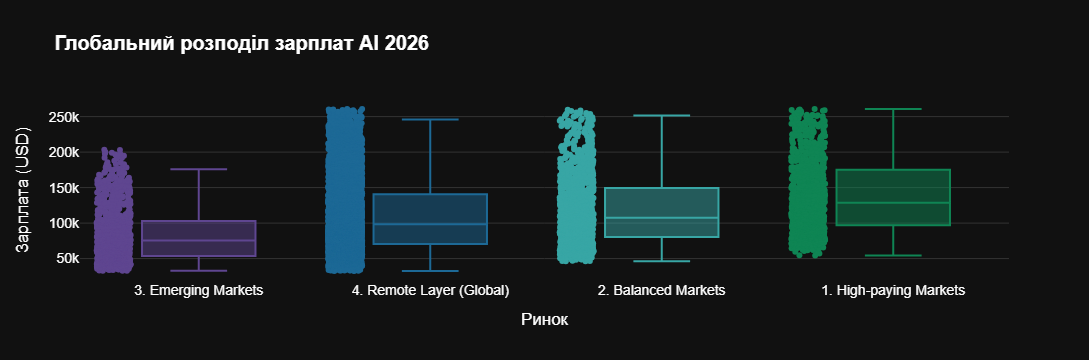

In [42]:
import plotly.express as px
category_order = plot_data.groupby('Category')['salary_usd'].median().sort_values().index

fig = px.box(plot_data, 
             x="Category", 
             y="salary_usd", 
             color="Category",
             category_orders={"Category": category_order},
             points="all",
             title="<b>Глобальний розподіл зарплат AI 2026</b>",
             labels={"salary_usd": "Зарплата (USD)", "Category": "Ринок"},
             color_discrete_sequence=px.colors.qualitative.Prism)

fig.update_layout(
    template="plotly_dark", 
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='#111111',
    font=dict(family="Arial", size=14, color="white"),
    showlegend=False,
    yaxis=dict(gridcolor='#333333', zerolinecolor='#333333')
)

fig.show()


📝 ВИСНОВКИ ДОСЛІДЖЕННЯ: ГЛОБАЛЬНИЙ РИНОК AI ТА РОЛЬ REMOTE (2025-2026)
================================================================================

✅ 1. КЛАСТЕР ВИСОКОПРИБУТКОВИХ РИНКІВ (USA, SWITZERLAND):
Дані підтверджують стійку лідерську позицію США та Швейцарії. Високий рівень компенсацій 
на рівні EX (Executive) корелює з високою вартістю життя та концентрацією капіталу в R&D. 
Ці ринки залишаються еталонними для оцінки максимальної капіталізації фахівців.

✅ 2. КЛАСТЕР СТАБІЛЬНИХ РИНКІВ (GERMANY, UK):
Ринки Західної Європи демонструють помірну волатильність. Статистично підтверджено, 
що рівень оплати праці Senior-спеціалістів у Великій Британії наближається до 
показників США, що робить цей регіон ключовим хабом для фахівців середньої та вищої ланки.

✅ 3. ФЕНОМЕН EMERGING MARKETS (Індія, Китай, Бразилія):
Попри низькі стартові зарплати, показник Exp_Premium % тут найвищий (99%). 
Це підтверджує гіпотезу: досвід у цих регіонах є дефіцитним ресурсом, тому розрив 
між Junior та Senior значно суттєвіший, ніж у розвинених країнах (+89% у США).

✅ 4. REMOTE LAYER ЯК ЕКВАЛАЙЗЕР:
Global Remote ($61K для EN) виступає "золотою серединою". Фахівці отримують більше, 
ніж у слабких економіках, але компанії економлять порівняно з топ-ринками. 
Це і є реальне "вирівнювання ринку" штучним інтелектом та цифровою свободою.

🏆 ЗАГАЛЬНИЙ ПІДСУМОК:
Ринок рухається до глобалізації, але географія все ще диктує правила. Найбільший 
фінансовий виграш сьогодні дає або фізичний переїзд у High-paying країни, 
або робота на глобальний Remote-ринок, знаходячись у локаціях з низькими витратами.

================================================================================